# 🏪 Big Mart Retail Sales Dashboard
## Level 1- Data Understanding
**Internship:** Business Analytics | Sysslan IT Solutions  
**Dataset:** Big Mart Sales Data  
**Objective:** Load the dataset, understand its structure, identify data quality issues, and generate basic descriptive statistics.

In [31]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings .filterwarnings ('ignore')

print('DONE')

DONE


In [38]:
### Data load
df = pd.read_csv('Big_Mart_Sales.csv')
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print('Data loaded sucessfully')

Rows: 5681, Columns: 11
Data loaded sucessfully


In [6]:
### first 5 rows 
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,FDW58,20.750,Low Fat,0.007565,Snack Foods,107.8622,OUT049,1999,Medium,Tier 1,Supermarket Type1
1,FDW14,8.300,reg,0.038428,Dairy,87.3198,OUT017,2007,NaN,Tier 2,Supermarket Type1
2,NCN55,14.600,Low Fat,0.099575,Others,241.7538,OUT010,1998,NaN,Tier 3,Grocery Store
3,FDQ58,7.315,Low Fat,0.015388,Snack Foods,155.0340,OUT017,2007,NaN,Tier 2,Supermarket Type1
4,FDY38,NaN,Regular,0.118599,Dairy,234.2300,OUT027,1985,Medium,Tier 3,Supermarket Type3


In [10]:
### Column types
df.dtypes

Item_Identifier               object
Item_Weight                  float64
Item_Fat_Content              object
Item_Visibility              float64
Item_Type                     object
Item_MRP                     float64
Outlet_Identifier             object
Outlet_Establishment_Year      int64
Outlet_Size                   object
Outlet_Location_Type          object
Outlet_Type                   object
dtype: object

In [16]:
# Dataset info
print(' Dataset Info:')
df.info()

 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5681 entries, 0 to 5680
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            5681 non-null   object 
 1   Item_Weight                4705 non-null   float64
 2   Item_Fat_Content           5681 non-null   object 
 3   Item_Visibility            5681 non-null   float64
 4   Item_Type                  5681 non-null   object 
 5   Item_MRP                   5681 non-null   float64
 6   Outlet_Identifier          5681 non-null   object 
 7   Outlet_Establishment_Year  5681 non-null   int64  
 8   Outlet_Size                4075 non-null   object 
 9   Outlet_Location_Type       5681 non-null   object 
 10  Outlet_Type                5681 non-null   object 
dtypes: float64(3), int64(1), object(7)
memory usage: 488.3+ KB


In [24]:
### Missing value count and percentage
missing = pd.DataFrame({
      'Missing Count' : df.isnull().sum(),
      'Missing %' :  (df.isnull().sum() / len(df) * 100).round(2)
})
missing[missing['Missing Count'] > 0]

,Missing Count,Missing %
Item_Weight,976,17.18
Outlet_Size,1606,28.27


In [26]:
### Duplicates
print(f"Duplicate rows:{df.duplicated().sum()}")

Duplicate rows:0


In [21]:
### Inconsistent Values
print(df['Item_Fat_Content'].value_counts

Item_Fat_Content
Low Fat    3396
Regular    1935
LF          206
reg          78
low fat      66
Name: count, dtype: int64


In [22]:
### Descriptive Statistics
df.describe().round(2)

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year
count,4705.00,5681.00,5681.00,5681.00
mean,12.70,0.07,141.02,1997.83
std,4.66,0.05,61.81,8.37
min,4.56,0.00,31.99,1985.00
25%,8.64,0.03,94.41,1987.00
50%,12.50,0.05,141.42,1999.00
75%,16.70,0.09,186.03,2004.00
max,21.35,0.32,266.59,2009.00


In [29]:
# Other categorical columns
cat_cols = ['Item_Type', 'Outlet_Type', 'Outlet_Size', 'Outlet_Location_Type']
for col in cat_cols:
    print(f'\n📌 {col}:')
    print(df[col].value_counts())


📌 Item_Type:
Item_Type
Snack Foods              789
Fruits and Vegetables    781
Household                638
Frozen Foods             570
Dairy                    454
Baking Goods             438
Canned                   435
Health and Hygiene       338
Meat                     311
Soft Drinks              281
Breads                   165
Hard Drinks              148
Starchy Foods            121
Others                   111
Breakfast                 76
Seafood                   25
Name: count, dtype: int64

📌 Outlet_Type:
Outlet_Type
Supermarket Type1    3717
Grocery Store         722
Supermarket Type3     624
Supermarket Type2     618
Name: count, dtype: int64

📌 Outlet_Size:
Outlet_Size
Medium    1862
Small     1592
High       621
Name: count, dtype: int64

📌 Outlet_Location_Type:
Outlet_Location_Type
Tier 3    2233
Tier 2    1856
Tier 1    1592
Name: count, dtype: int64


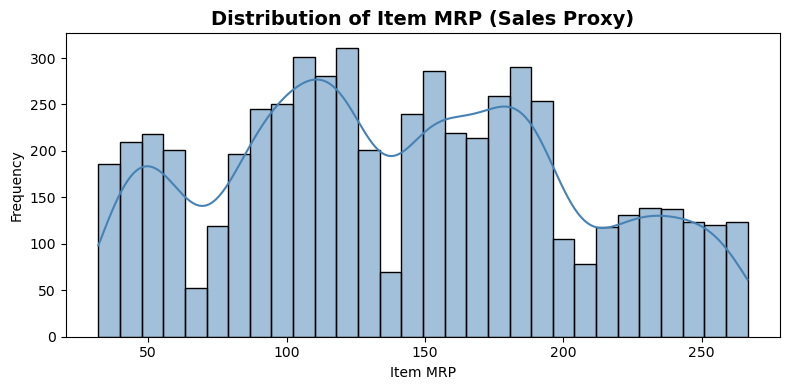


💰 Average Item MRP: ₹141.02
💰 Max Item MRP: ₹266.59
💰 Min Item MRP: ₹31.99


In [32]:
# Distribution of Item_MRP (our sales proxy)
plt.figure(figsize=(8, 4))
sns.histplot(df['Item_MRP'], bins=30, color='steelblue', kde=True)
plt.title('Distribution of Item MRP (Sales Proxy)', fontsize=14, fontweight='bold')
plt.xlabel('Item MRP')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f'\n💰 Average Item MRP: ₹{df["Item_MRP"].mean():.2f}')
print(f'💰 Max Item MRP: ₹{df["Item_MRP"].max():.2f}')
print(f'💰 Min Item MRP: ₹{df["Item_MRP"].min():.2f}')

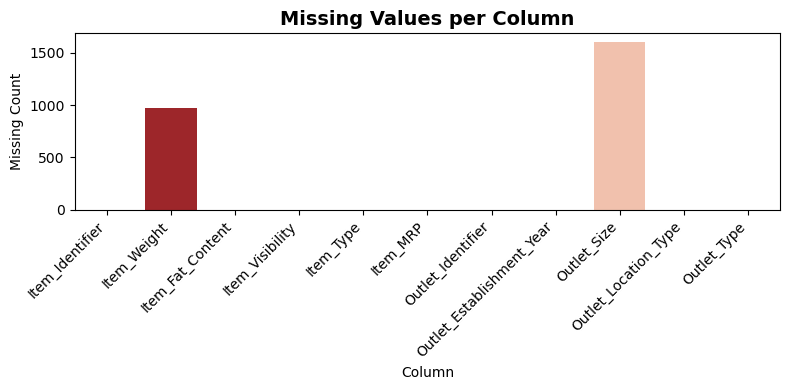

In [37]:
# Visualize missing values
plt.figure(figsize=(8, 4))
sns.barplot(x=missing.index, y=missing['Missing Count'], palette='Reds_r')
plt.title('Missing Values per Column', fontsize=14, fontweight='bold')
plt.xlabel('Column')
plt.ylabel('Missing Count')
plt.xticks(rotation= 45, ha='right')
plt.tight_layout()
plt.show()